In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
data = pd.read_parquet("../raw_data/data_binance.parquet")

#### Validation

In [18]:
float_cols = ["open", "high", "low", "close",
              "volume", "quote_asset_volume",
              "taker_buy_base", "taker_buy_quote"]
int_cols = ["trades"]

def check_df(df, name):
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    assert np.issubdtype(df["timestamp"].dtype, np.datetime64), \
        f"{name}: timestamp is not datetime64"

    for c in float_cols:
        assert np.issubdtype(df[c].dtype, np.number), \
            f"{name}: column {c} is not numeric"

    for c in int_cols:
        assert (np.issubdtype(df[c].dtype, np.integer) or
                np.issubdtype(df[c].dtype, np.number)), \
            f"{name}: column {c} is not integer-like"

    print(f"""{name}:
✅ timestamp variable has datetime64 type
✅ trades variable has integer-like type
✅ other variables belong to float type
""")

check_df(data, "data")

data:
✅ timestamp variable has datetime64 type
✅ trades variable has integer-like type
✅ other variables belong to float type



In [19]:
num_cols_non_negative = ["open", "high", "low", "close",
                         "volume", "quote_asset_volume",
                         "taker_buy_base", "taker_buy_quote"]

def content_check(df, name):
    assert not df.isna().any().any(), "there are NaN :("

    str_cols = df.select_dtypes(include=["object"]).columns
    for c in str_cols:
        assert not (df[c].astype(str).str.strip() == "").any(), f"empty rows {c}"

    zero_counts = {}
    for c in num_cols_non_negative:
        assert (df[c] >= 0).all(), f"Negative values {c}"
        zero_counts[c] = int((df[c] == 0).sum())

    n_obs = len(df)
    print(f"""{name}:
✅no NaN
✅no empty values
✅no negative values
Total number of observations: {n_obs}
Zero values:
""")
    for col, cnt in zero_counts.items():
        print(f"  - {col}: {cnt} zeros")
    print()

content_check(data, "data")

data:
✅no NaN
✅no empty values
✅no negative values
Total number of observations: 587596
Zero values:

  - open: 0 zeros
  - high: 0 zeros
  - low: 0 zeros
  - close: 0 zeros
  - volume: 31 zeros
  - quote_asset_volume: 31 zeros
  - taker_buy_base: 31 zeros
  - taker_buy_quote: 31 zeros



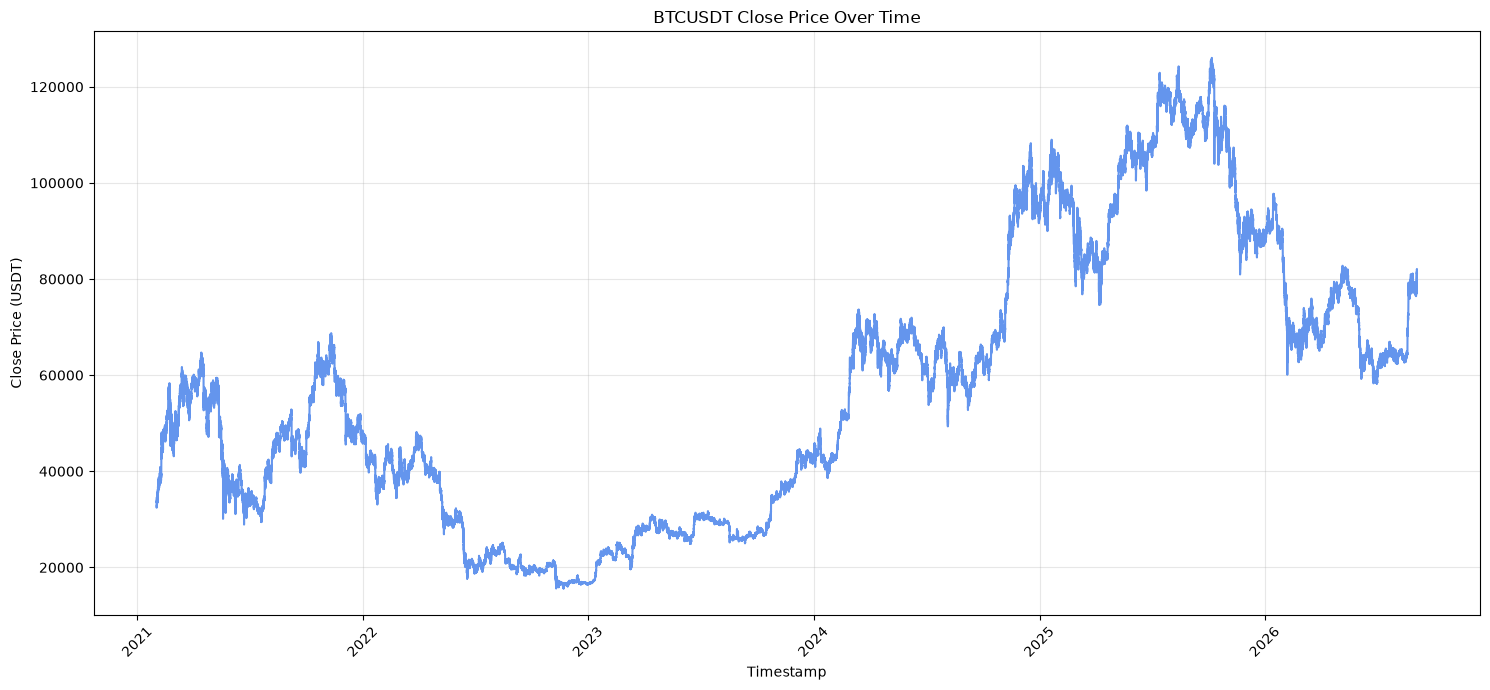

In [20]:
plt.figure(figsize=(15, 7))
plt.plot(data['timestamp'], data['close'], color = 'cornflowerblue')
plt.title('BTCUSDT Close Price Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Close Price (USDT)')
plt.xticks(rotation = 45)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

In [21]:
data.set_index('timestamp', inplace=True)

In [22]:
def get_rv_4h_log(df):
    d = df.copy()

    # 2. calculating log values
    # log_ret = ln(P_t) - ln(P_{t-1})
    d["log_ret"] = np.log(d["close"]).diff()

    # 3. deleting nan
    d = d.dropna(subset=["log_ret"])

    # 4. applying RV formula
    # .resample("4H") создаст бакеты: 00:00, 04:00, 08:00 и т.д.
    data = np.sqrt(d["log_ret"].pow(2).resample("4h").sum()).to_frame(name="RV")

    # 5. calculating logarithm values from RV
    data["log_RV"] = np.log(data["RV"])

    
    data["volume"] = d["volume"].resample("4h").sum()
    data["trades"] = d["trades"].resample("4h").sum()

    return data

In [23]:
data_4h = get_rv_4h_log(data)

In [24]:
def validate_rv_data(df):
    # 1. Check: Is the dataframe empty?
    assert not df.empty, "Validation Error: The dataframe is empty!"

    # 2. Check: Presence of NaNs
    nan_count = df.isna().sum().sum()
    assert nan_count == 0, f"Validation Error: Found {nan_count} NaN values!"

    # 3. Check: Presence of Infinities (inf, -inf)
    # Common when RV is 0 and you take np.log(0)
    inf_count = np.isinf(df).values.sum()
    assert inf_count == 0, f"Validation Error: Found {inf_count} infinite values (inf/-inf)!"

    # 4. Check: Chronology (Is the index strictly increasing?)
    assert df.index.is_monotonic_increasing, "Validation Error: Chronology broken! Index is not monotonically increasing."

    # 5. Check: Unique Timestamps
    assert df.index.is_unique, "Validation Error: Duplicate timestamps found in the index."

    # 6. Check: Frequency Consistency (Strict 4H intervals)
    if len(df) > 1:
        # Calculate the difference between consecutive timestamps
        time_deltas = pd.Series(df.index).diff().dropna()
        expected_delta = pd.Timedelta("4h")

        # Ensure every gap is exactly 4 hours
        is_consistent = (time_deltas == expected_delta).all()
        assert is_consistent, "Validation Error: Gap detected! The 4H frequency is inconsistent or bars are missing."

    print("✅ All checks passed: Data is clean, chronological, and ready for analysis.")

In [25]:
validate_rv_data(data_4h)

✅ All checks passed: Data is clean, chronological, and ready for analysis.


In [26]:
data_4h.to_parquet("resampled_data_4h.parquet")